<a href="https://colab.research.google.com/github/SrustiUB/Data-Science/blob/main/Bangalore_apartment_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


In [ ]:
df=pd.read_csv("blore_house_data.csv")

In [ ]:
# Force both columns to be numeric; anything else becomes NaN
df['area'] = pd.to_numeric(df['area'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')# Drop rows where 'area' or 'price' has a NaN value
df['Age (Years)']= pd.to_numeric(df['Age (Years)'], errors="coerce")
df['BHK']=pd.to_numeric(df['BHK'],errors='coerce')

In [ ]:
import math
median_area = math.floor(df.area.median())
median_area
df.area=df.area.fillna(median_area)


In [ ]:
median_bhk= math.floor(df.BHK.median())
median_bhk
df.BHK=df.BHK.fillna(median_bhk)

In [ ]:
median_price = math.floor(df.price.median())
median_price
df.price=df.price.fillna(median_price)
df.price.head(11)

,price
0,4032500.0
1,6500000.0
2,7167000.0
3,8000000.0
4,12562500.0
5,12550000.0
6,4788000.0
7,9510000.0
8,7650000.0
9,10900000.0


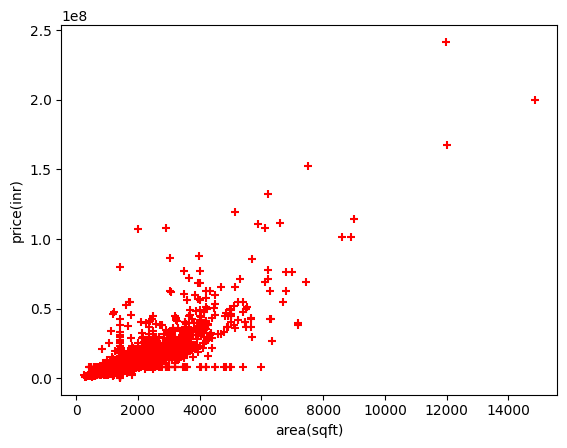

In [ ]:
%matplotlib inline
plt.xlabel("area(sqft)")
plt.ylabel("price(inr)")
plt.scatter(df.area,df.price, color="red",marker="+")

In [ ]:

reg=linear_model.LinearRegression()
reg.fit(df[["area"]],df.price)

LinearRegression()

In [ ]:
reg.predict([[2000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([14559754.23269373])

In [ ]:
reg.coef_

array([10754.39049097])

In [ ]:
reg.intercept_

np.float64(-6949026.749253333)

In [ ]:
10676.83647489*2000-7130491.927838482

14223181.02194152

In [ ]:
areas=np.array([1200,2050,3000])
areas2d=areas.reshape(-1,1)
reg.predict(areas2d)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 5956241.8399149 , 15097473.75724241, 25314144.72366726])

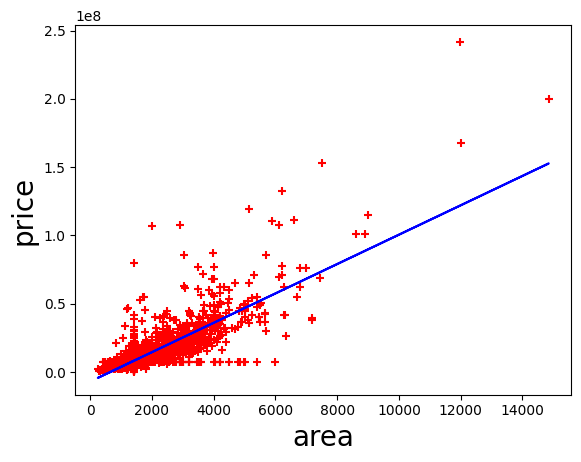

In [ ]:
%matplotlib inline
plt.xlabel('area',fontsize=20)
plt.ylabel('price',fontsize=20)
plt.scatter(df.area,df.price,color='red',marker='+')
plt.plot(df.area,reg.predict(df[['area']]),color='blue')

In [ ]:
d=pd.read_csv("areas.csv")
d.head(3)


,area
0,1000
1,1500
2,2300


In [ ]:
p=reg.predict(d)

In [ ]:
d['prices']=p

In [ ]:
d.to_csv("prediction.csv",index=False)

Multiple  Regression


In [ ]:
#we did push fill na
reg=linear_model.LinearRegression()
reg.fit(df[["area",'BHK','Age (Years)']],df.price)

LinearRegression()

In [ ]:
reg.predict([[3000,3,4]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([28456799.09281866])

In [ ]:
reg.intercept_

np.float64(7597155.677171909)

In [ ]:
reg.coef_

array([   11282.64537372, -3784859.16797365,  -408428.80039561])

In [ ]:
11282.64537372*3000-3784859.16797365*3-408428.80039561*4+7597155.677171909

28456799.09282852